In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

In [13]:
df = pd.read_csv('/kaggle/input/electric-production/Electric_Production.csv')
df.columns = ['Date', 'Production']
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)
print(df.shape)
df.head()

(397, 1)


,Production
Date,
1985-01-01,72.5052
1985-02-01,70.6720
1985-03-01,62.4502
1985-04-01,57.4714
1985-05-01,55.3151


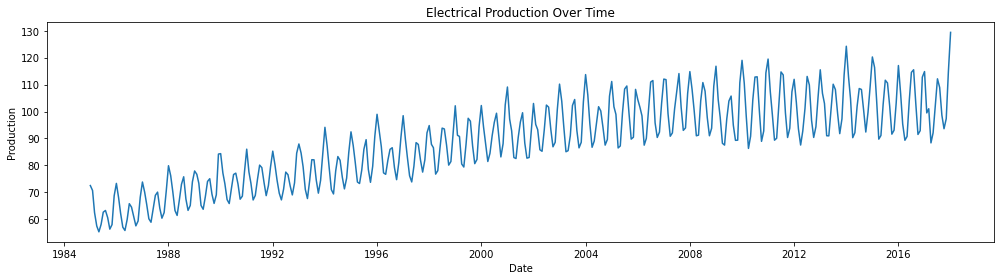

In [14]:
plt.figure(figsize=(14,4))
plt.plot(df['Production'])
plt.title('Electrical Production Over Time')
plt.xlabel('Date')
plt.ylabel('Production')
plt.tight_layout()
plt.show()

In [15]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df[['Production']].values)

SEQ_LEN = 24
FUTURE_STEPS = 120  # 10 years monthly

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, SEQ_LEN)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


In [16]:
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc  = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc   = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc  = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

In [17]:
class PatchEmbedding(nn.Module):
    def __init__(self, seq_len, patch_size, d_model):
        super().__init__()
        self.patch_size = patch_size
        num_patches = seq_len // patch_size
        self.proj = nn.Linear(patch_size, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, d_model))

    def forward(self, x):
        B, T, C = x.shape
        x = x.squeeze(-1)
        patches = x.unfold(1, self.patch_size, self.patch_size)
        x = self.proj(patches)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_embed
        return x

class VisionTransformer(nn.Module):
    def __init__(self, seq_len=24, patch_size=4, d_model=64, nhead=4, num_layers=2, output_size=1):
        super().__init__()
        self.patch_embed = PatchEmbedding(seq_len, patch_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                    dim_feedforward=128, dropout=0.1)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, output_size)

    def forward(self, x):
        x = self.patch_embed(x)
        x = x.permute(1, 0, 2)        # (seq, batch, d_model) for older PyTorch
        x = self.transformer(x)
        x = x.permute(1, 0, 2)        # back to (batch, seq, d_model)
        return self.fc(x[:, 0, :])

In [18]:
def train_model(model, train_dl, epochs=50, lr=1e-3):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    losses = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg = epoch_loss / len(train_dl)
        losses.append(avg)
        if (epoch+1) % 10 == 0:
            print(f'Epoch {epoch+1}/{epochs} | Loss: {avg:.6f}')
    return losses

def evaluate(model, X_test_t, y_test_t):
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t.to(DEVICE)).cpu().numpy()
    actuals = y_test_t.numpy()
    preds_inv = scaler.inverse_transform(preds)
    actuals_inv = scaler.inverse_transform(actuals)
    rmse = math.sqrt(mean_squared_error(actuals_inv, preds_inv))
    mae  = mean_absolute_error(actuals_inv, preds_inv)
    r2   = r2_score(actuals_inv, preds_inv)
    print(f'  RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}')
    return preds_inv, actuals_inv

def forecast_future(model, last_sequence, steps, scaler):
    model.eval()
    seq = last_sequence.copy()
    future = []
    for _ in range(steps):
        inp = torch.tensor(seq[-SEQ_LEN:].reshape(1, SEQ_LEN, 1), dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            pred = model(inp).cpu().numpy()
        future.append(pred[0, 0])
        seq = np.append(seq, pred[0, 0])
    future = np.array(future).reshape(-1, 1)
    return scaler.inverse_transform(future)

In [19]:
print('=== Training RNN ===')
rnn_model = RNNModel()
rnn_losses = train_model(rnn_model, train_dl, epochs=50)
print('RNN Test Metrics:')
rnn_preds, rnn_actuals = evaluate(rnn_model, X_test_t, y_test_t)

=== Training RNN ===
Epoch 10/50 | Loss: 0.010322
Epoch 20/50 | Loss: 0.003106
Epoch 30/50 | Loss: 0.004267
Epoch 40/50 | Loss: 0.002543
Epoch 50/50 | Loss: 0.002606
RNN Test Metrics:
  RMSE: 4.2517 | MAE: 2.9675 | R2: 0.8033


In [20]:
print('=== Training LSTM ===')
lstm_model = LSTMModel()
lstm_losses = train_model(lstm_model, train_dl, epochs=50)
print('LSTM Test Metrics:')
lstm_preds, lstm_actuals = evaluate(lstm_model, X_test_t, y_test_t)

=== Training LSTM ===
Epoch 10/50 | Loss: 0.016848
Epoch 20/50 | Loss: 0.012291
Epoch 30/50 | Loss: 0.011941
Epoch 40/50 | Loss: 0.011618
Epoch 50/50 | Loss: 0.011112
LSTM Test Metrics:
  RMSE: 9.6214 | MAE: 8.1022 | R2: -0.0073


In [21]:
print('=== Training GRU ===')
gru_model = GRUModel()
gru_losses = train_model(gru_model, train_dl, epochs=50)
print('GRU Test Metrics:')
gru_preds, gru_actuals = evaluate(gru_model, X_test_t, y_test_t)

=== Training GRU ===
Epoch 10/50 | Loss: 0.013259
Epoch 20/50 | Loss: 0.010718
Epoch 30/50 | Loss: 0.010288
Epoch 40/50 | Loss: 0.011278
Epoch 50/50 | Loss: 0.010115
GRU Test Metrics:
  RMSE: 10.4013 | MAE: 8.2706 | R2: -0.1772


In [22]:
print('=== Training Vision Transformer ===')
vit_model = VisionTransformer(seq_len=SEQ_LEN, patch_size=4, d_model=64, nhead=4, num_layers=2)
vit_losses = train_model(vit_model, train_dl, epochs=50)
print('ViT Test Metrics:')
vit_preds, vit_actuals = evaluate(vit_model, X_test_t, y_test_t)

=== Training Vision Transformer ===
Epoch 10/50 | Loss: 0.015656
Epoch 20/50 | Loss: 0.014289
Epoch 30/50 | Loss: 0.010550
Epoch 40/50 | Loss: 0.013823
Epoch 50/50 | Loss: 0.007272
ViT Test Metrics:
  RMSE: 7.4347 | MAE: 6.2511 | R2: 0.3985


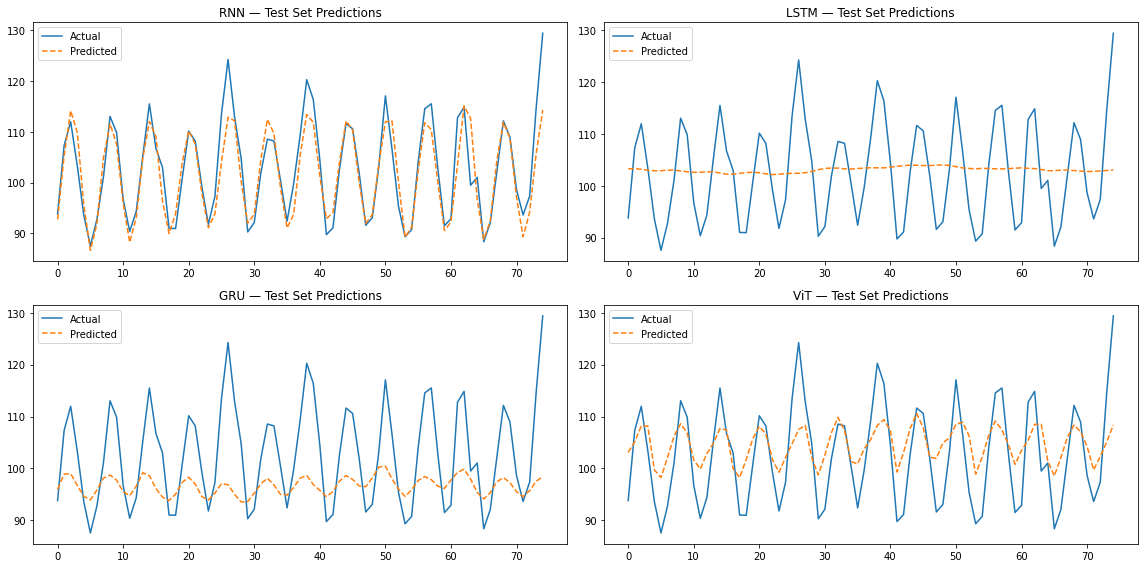

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
models_info = [
    ('RNN',  rnn_preds,  rnn_actuals,  rnn_losses),
    ('LSTM', lstm_preds, lstm_actuals, lstm_losses),
    ('GRU',  gru_preds,  gru_actuals,  gru_losses),
    ('ViT',  vit_preds,  vit_actuals,  vit_losses),
]
for ax, (name, preds, actuals, _) in zip(axes.flatten(), models_info):
    ax.plot(actuals, label='Actual', linewidth=1.5)
    ax.plot(preds,   label='Predicted', linewidth=1.5, linestyle='--')
    ax.set_title(f'{name} — Test Set Predictions')
    ax.legend()
plt.tight_layout()
plt.show()

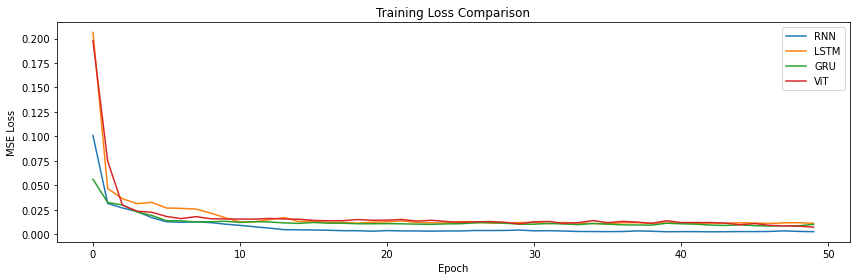

In [24]:
plt.figure(figsize=(12, 4))
for name, _, _, losses in models_info:
    plt.plot(losses, label=name)
plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
last_seq = data_scaled[-SEQ_LEN:]

rnn_future  = forecast_future(rnn_model,  last_seq, FUTURE_STEPS, scaler)
lstm_future = forecast_future(lstm_model, last_seq, FUTURE_STEPS, scaler)
gru_future  = forecast_future(gru_model,  last_seq, FUTURE_STEPS, scaler)
vit_future  = forecast_future(vit_model,  last_seq, FUTURE_STEPS, scaler)

last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=FUTURE_STEPS, freq='MS')

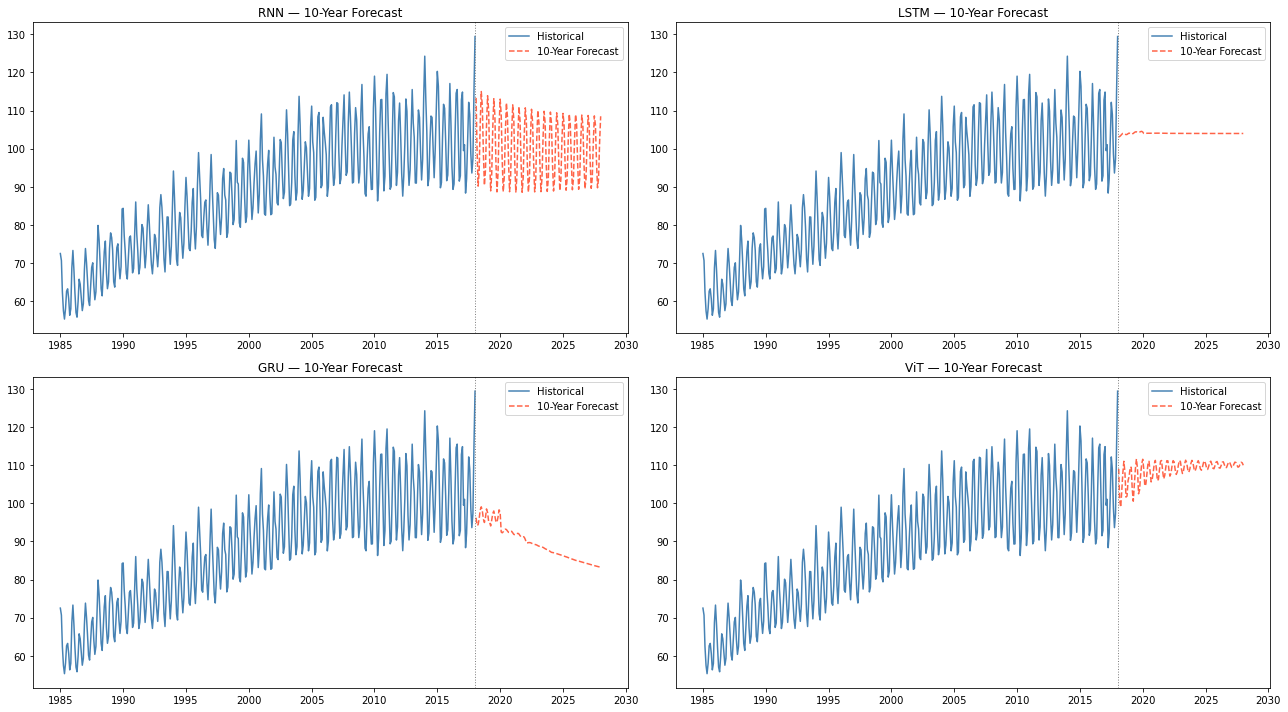

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
futures = [
    ('RNN',  rnn_future),
    ('LSTM', lstm_future),
    ('GRU',  gru_future),
    ('ViT',  vit_future),
]
for ax, (name, future) in zip(axes.flatten(), futures):
    ax.plot(df.index, df['Production'], label='Historical', color='steelblue')
    ax.plot(future_dates, future.flatten(), label='10-Year Forecast', color='tomato', linestyle='--')
    ax.axvline(x=last_date, color='gray', linestyle=':', linewidth=1)
    ax.set_title(f'{name} — 10-Year Forecast')
    ax.legend()
plt.tight_layout()
plt.show()

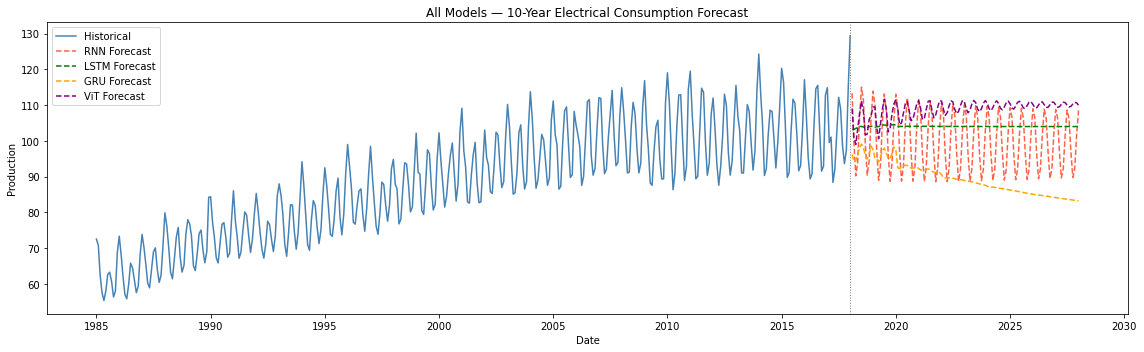

In [27]:
plt.figure(figsize=(16, 5))
plt.plot(df.index, df['Production'], label='Historical', color='steelblue', linewidth=1.5)
colors = ['tomato', 'green', 'orange', 'purple']
for (name, future), color in zip(futures, colors):
    plt.plot(future_dates, future.flatten(), label=f'{name} Forecast', color=color, linestyle='--')
plt.axvline(x=last_date, color='gray', linestyle=':', linewidth=1)
plt.title('All Models — 10-Year Electrical Consumption Forecast')
plt.xlabel('Date')
plt.ylabel('Production')
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
metrics_data = []
for name, preds, actuals, _ in models_info:
    rmse = math.sqrt(mean_squared_error(actuals, preds))
    mae  = mean_absolute_error(actuals, preds)
    r2   = r2_score(actuals, preds)
    metrics_data.append({'Model': name, 'RMSE': round(rmse,4), 'MAE': round(mae,4), 'R2': round(r2,4)})

metrics_df = pd.DataFrame(metrics_data)
print(metrics_df.to_string(index=False))

Model     RMSE     MAE      R2
  RNN   4.2517  2.9675  0.8033
 LSTM   9.6214  8.1022 -0.0073
  GRU  10.4013  8.2706 -0.1772
  ViT   7.4347  6.2511  0.3985


In [29]:
forecast_df = pd.DataFrame({'Date': future_dates})
for name, future in futures:
    forecast_df[name] = future.flatten()
forecast_df.set_index('Date', inplace=True)
print(forecast_df.head(12))

                   RNN        LSTM        GRU         ViT
Date                                                     
2018-02-01  113.314957  103.119072  96.198479  109.020355
2018-03-01   99.847153  103.173782  94.203537  100.963249
2018-04-01   90.178970  103.438774  94.368896   98.982368
2018-05-01   94.033470  103.760406  95.946388  103.220573
2018-06-01  106.638672  104.002953  98.246063  107.834259
2018-07-01  114.985939  104.007904  99.069633  111.003883
2018-08-01  111.214333  103.847153  98.048264  108.170830
2018-09-01   98.869873  103.684311  95.835388  101.620445
2018-10-01   90.396225  103.730659  94.958328  101.877991
2018-11-01   94.449615  103.935265  96.290939  105.975761
2018-12-01  106.206421  104.090225  98.510818  107.009010
2019-01-01  113.883339  103.952133  97.567200  109.475494


In [30]:
forecast_df.to_csv('10_year_forecast.csv')
print('Forecast saved to 10_year_forecast.csv')

Forecast saved to 10_year_forecast.csv
